# Lloyd QPE: Unitary vs Semi-classical IQFT

Comparison of two Lloyd-style QPE implementations from [arXiv:1910.11696](https://arxiv.org/abs/1910.11696) (*An Improved Implementation Approach for QPE on NISQ*, Mohammadbagherpoor et al.).

| Method | Paper | Implementation |
|--------|-------|----------------|
| Lloyd + inverse QFT | Sec. II-C, Fig. 9 | `method="lloyd"` — unitary IQFT, measure at end |
| **Modified Lloyd** (semi-classical IQFT) | Fig. 11 | `method="lloyd_semclassical"` — MCM + `if_test` feed-forward |

Paper benchmark: **φ = 11/16 = 0.1011₂** on eigenstate |1⟩ (Sec. III). Both methods should return `1011` ideally; the semi-classical variant trades some two-qubit entanglement in IQFT for dynamic feed-forward gates.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

from qsp_core import profile_circuit
from dynamic_qpe import (
    expected_bits,
    build_paper_demo_circuit,
    estimate_phase_from_counts,
)

LLOYD_METHODS = ["lloyd", "lloyd_semclassical"]

# --- demo parameters (notebook-owned) ---
PAPER_BITS = 8
PAPER_DEMO_PHI = 11.0 / 16.0  # φ = 0.1011₂ (paper Sec. III)
TARGET_BITS = expected_bits(PAPER_DEMO_PHI, PAPER_BITS)
SHOTS = 5000
SEED = 42


def build_demo_qc(method: str):
    return build_paper_demo_circuit(PAPER_BITS, method=method, phi=PAPER_DEMO_PHI)

sim_ideal = AerSimulator(method="statevector")

service = QiskitRuntimeService(name="YONSEI-SKQD")
backend = service.backend("ibm_yonsei")
backend_sim = AerSimulator().from_backend(backend)
pm = generate_preset_pass_manager(
    target=backend_sim.target,
    optimization_level=3,
    seed_transpiler=SEED,
    layout_method="sabre",
)
print(backend_sim)
print(f"Target: φ={PAPER_DEMO_PHI:.4f}  bits={TARGET_BITS}")


AerSimulator('aer_simulator_from(ibm_yonsei)'
             noise_model=<NoiseModel on ['id', 'reset', 'sx', 'measure', 'x', 'ecr']>)
Target: φ=0.6875  bits=10110000


## 1. Ideal comparison — φ = 11/16

Sec. III: `φ = 1/2 + 1/8 + 1/16 = 0.1011` on |1⟩. Unitary and semi-classical Lloyd should both peak at bitstring `1011`.


In [9]:
paper_rows = []
for method in LLOYD_METHODS:
    qc = build_demo_qc(method)
    counts = sim_ideal.run(transpile(qc, sim_ideal), shots=4096).result().get_counts()
    phi, prob, bits = estimate_phase_from_counts(counts, PAPER_BITS)
    ok = bits == TARGET_BITS
    paper_rows.append(dict(method=method, bits=bits, phi=phi, prob=prob, ok=ok))
    print(
        f"{method:22s}  bits={bits}  φ={phi:.4f}  P={prob:.3f}  "
        f"{'OK' if ok else 'miss'}"
    )

assert all(r["ok"] for r in paper_rows)


lloyd                   bits=10110000  φ=0.6875  P=1.000  OK
lloyd_semclassical      bits=10110000  φ=0.6875  P=1.000  OK


## 2. Resource profile & circuit diagrams

Fig. 11: modified Lloyd replaces controlled-Rz in IQFT with mid-circuit measure + `if_test` `P` gates (dynamic circuit).



LLOYD
  logical: {'depth': 11, 'depth_2q': 8, 'n_2q': 0, 'n_mcm': 8, 'n_reset': 0, 'n_if_else': 0}
  ISA:     {'depth': 305, 'depth_2q': 79, 'n_2q': 123, 'n_mcm': 8, 'n_reset': 0, 'n_if_else': 0}

LLOYD_SEMCLASSICAL
  logical: {'depth': 25, 'depth_2q': 8, 'n_2q': 0, 'n_mcm': 8, 'n_reset': 0, 'n_if_else': 28}
  ISA:     {'depth': 90, 'depth_2q': 14, 'n_2q': 17, 'n_mcm': 8, 'n_reset': 0, 'n_if_else': 28}


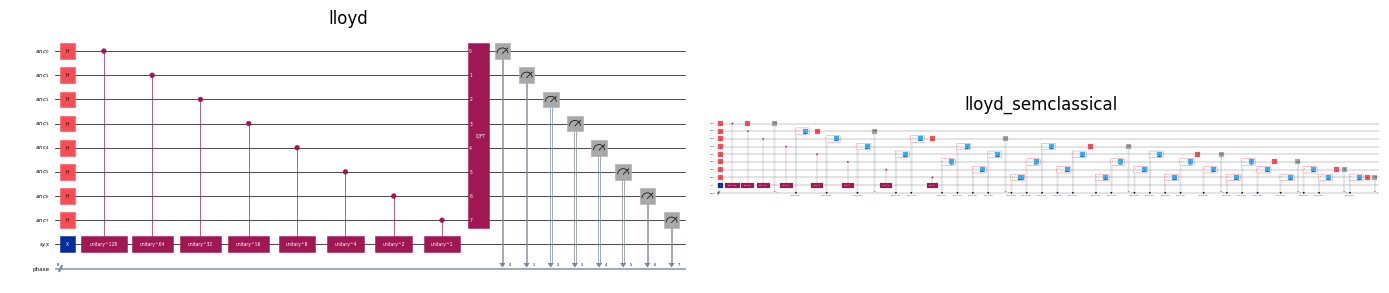

In [10]:
for method in LLOYD_METHODS:
    qc = build_demo_qc(method)
    logical = profile_circuit(qc)
    isa = profile_circuit(pm.run(qc))
    print(f"\n{method.upper()}")
    print(f"  logical: {logical}")
    print(f"  ISA:     {isa}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for ax, method in zip(axes, LLOYD_METHODS):
    qc = build_demo_qc(method)
    qc.draw("mpl", ax=ax, fold=-1)
    ax.set_title(method)
plt.tight_layout()


## 3. Noisy vs ideal (ibm_yonsei Aer)

Same φ = 11/16 benchmark: noiseless statevector vs `from_backend(ibm_yonsei)` ISA circuits.


In [11]:
def run_paper_qpe(method, shots, *, use_isa=False):
    qc = build_demo_qc(method)
    if use_isa:
        run_qc = pm.run(qc)
        pub = SamplerV2(mode=backend_sim).run([run_qc], shots=shots).result()[0]
        counts = dict(Counter(pub.data.phase.get_bitstrings()))
    else:
        counts = sim_ideal.run(transpile(qc, sim_ideal), shots=shots).result().get_counts()
    phi, prob, bits = estimate_phase_from_counts(counts, PAPER_BITS)
    return dict(method=method, counts=counts, phi=phi, prob=prob, bits=bits, ok=bits == TARGET_BITS)


rows = []
for mode, use_isa in [("ideal", False), ("noisy", True)]:
    for method in LLOYD_METHODS:
        r = run_paper_qpe(method, SHOTS, use_isa=use_isa)
        rows.append({"mode": mode, **r})
        print(
            f"{mode:5s} {method:22s}  bits={r['bits']}  φ={r['phi']:.4f}  "
            f"P={r['prob']:.3f}  {'OK' if r['ok'] else 'miss'}"
        )


ideal lloyd                   bits=10110000  φ=0.6875  P=1.000  OK
ideal lloyd_semclassical      bits=10110000  φ=0.6875  P=1.000  OK
noisy lloyd                   bits=10110000  φ=0.6875  P=0.211  OK
noisy lloyd_semclassical      bits=10110000  φ=0.6875  P=0.513  OK


## 4. Summary plot


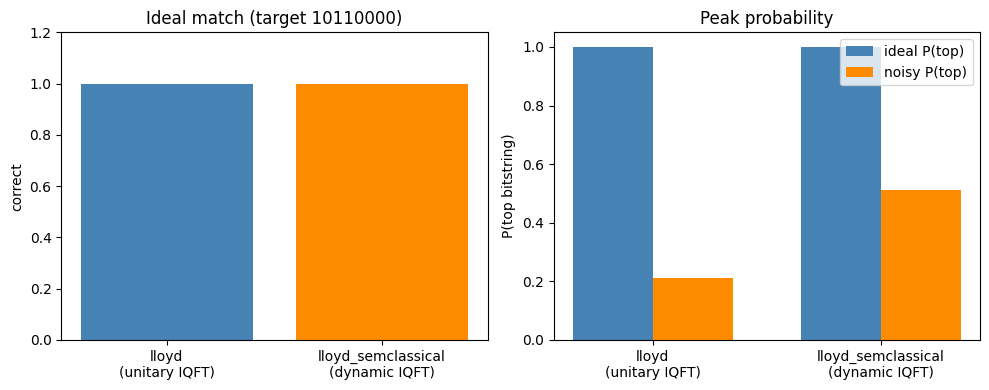

In [12]:
labels = ["lloyd\n(unitary IQFT)", "lloyd_semclassical\n(dynamic IQFT)"]
methods = [r["method"] for r in paper_rows]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ok_ideal = [1 if r["ok"] else 0 for r in paper_rows]
axes[0].bar(labels, ok_ideal, color=["steelblue", "darkorange"])
axes[0].set_ylim(0, 1.2)
axes[0].set_title(f"Ideal match (target {TARGET_BITS})")
axes[0].set_ylabel("correct")

ideal_p = [next(r["prob"] for r in rows if r["mode"] == "ideal" and r["method"] == m) for m in methods]
noisy_p = [next(r["prob"] for r in rows if r["mode"] == "noisy" and r["method"] == m) for m in methods]
x = np.arange(len(methods))
w = 0.35
axes[1].bar(x - w / 2, ideal_p, w, label="ideal P(top)", color="steelblue")
axes[1].bar(x + w / 2, noisy_p, w, label="noisy P(top)", color="darkorange")
axes[1].set_xticks(x, labels)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("P(top bitstring)")
axes[1].set_title("Peak probability")
axes[1].legend()
plt.tight_layout()


## 5. Takeaways

- **Lloyd (Fig. 9)** — n ancillas, unitary inverse QFT, single measurement block at the end (`n_if_else=0`).
- **Modified Lloyd (Fig. 11)** — same kickback prefix; IQFT replaced by low-to-high H → measure → `if_test` P on higher qubits (`n_if_else>0`, dynamic circuit).
- On **ideal** sim both recover φ = 11/16; on **noisy** hardware the unitary IQFT path is often more robust, while the dynamic variant saves entangling gates in the IQFT stage.

Code: `src/dynamic_iqpe.py` (`build_paper_demo_circuit`, `_append_semclassical_iqft`).


In [ ]:
# Optional: real hardware (DD off for dynamic circuits)
# sampler_hw = SamplerV2(mode=backend)
# sampler_hw.options.dynamical_decoupling.enable = False
# qc = build_demo_qc("lloyd_semclassical")
# job = sampler_hw.run([pm.run(qc)], shots=SHOTS)
# print(job.job_id())
